In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Loading dataset
df = pd.read_csv("Iris.csv") 

In [3]:
# Drop unnecessary columns
df.drop(['Id'], axis=1, inplace=True)

In [6]:
# Clean and map the 'Species' column
df['Species'] = df['Species'].str.strip().str.replace('Iris-', '', regex=False)
label_map = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
df['target'] = df['Species'].map(label_map)

# Check for unmapped or missing values
if df['target'].isnull().any():
    print("Waning!:Unmapped species found:", df[df['target'].isnull()]['Species'].unique())
    raise ValueError("Target mapping failed due to unexpected labels in 'Species'.")


C:\Users\maris\AppData\Local\Temp\ipykernel_14244\2693942780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='Set2')


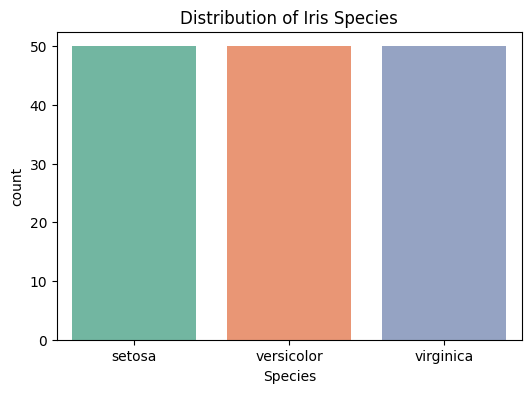

In [15]:
# Basic distribution of species
plt.figure(figsize=(6,4))
sns.countplot(x='Species', data=df, palette='Set2')
plt.title('Distribution of Iris Species')
plt.show()

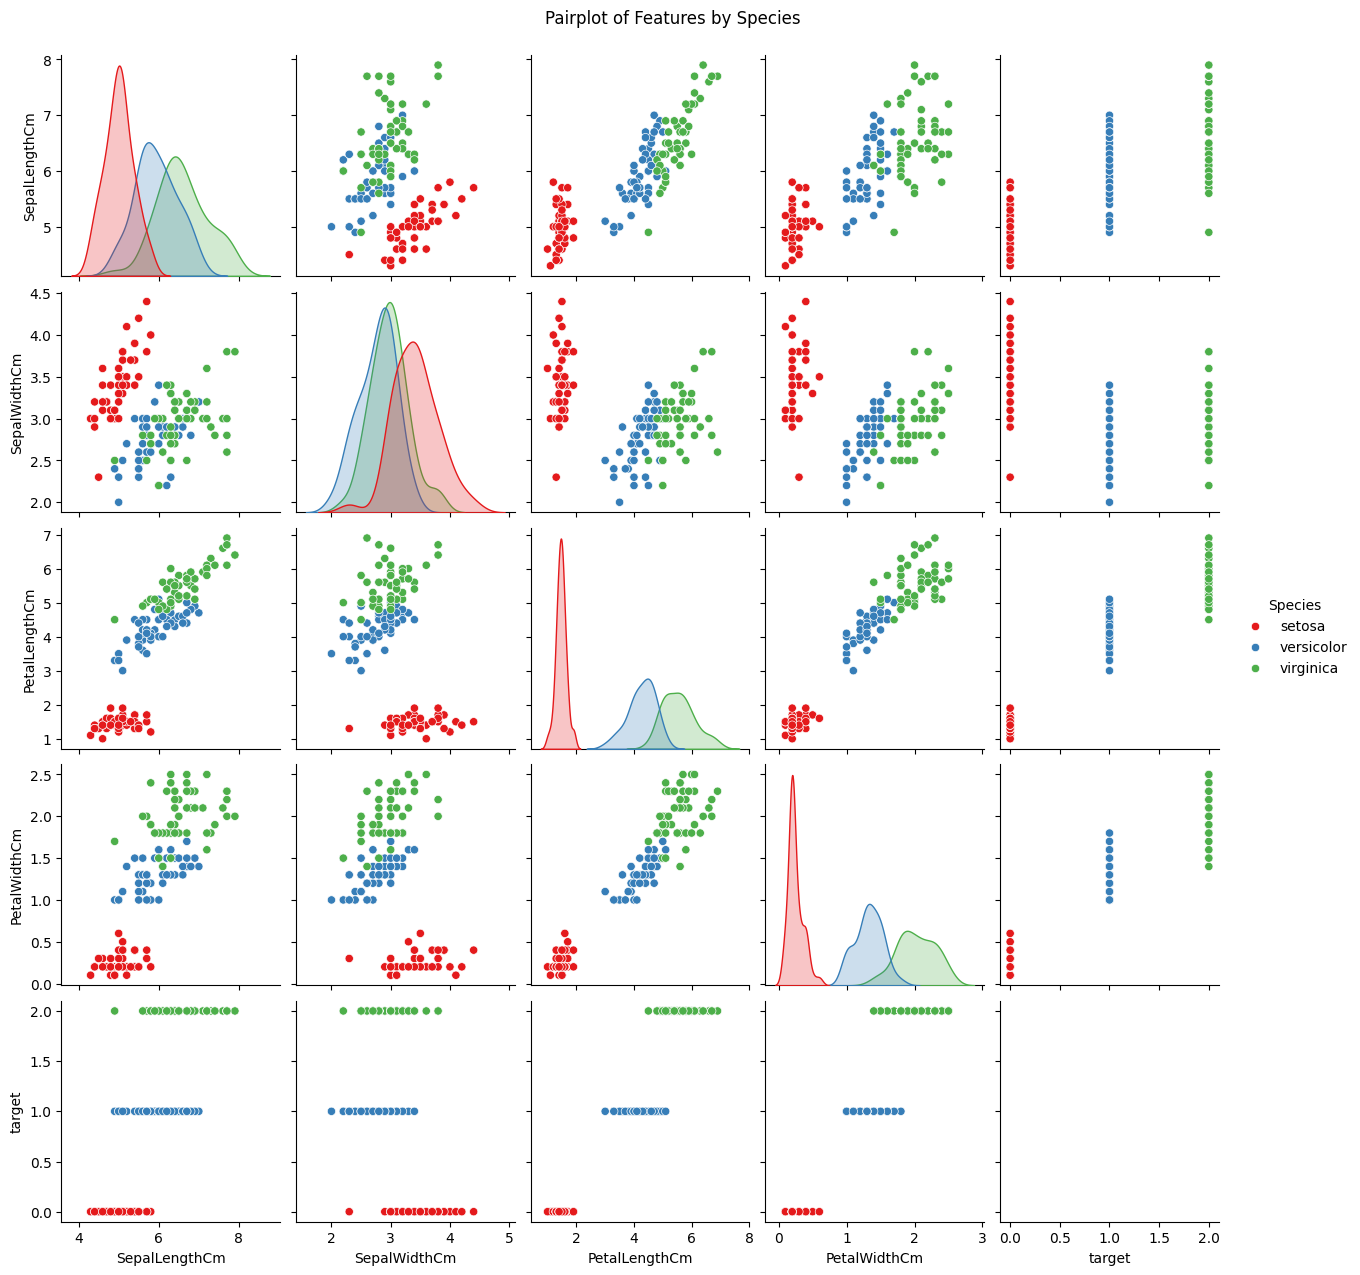

In [17]:
# Pair plot to visualize feature relationships by class
sns.pairplot(df, hue='Species', palette='Set1')
plt.suptitle('Pairplot of Features by Species', y=1.02)
plt.show()

In [7]:
# Prepare features and labels
X = df.drop(['Species', 'target'], axis=1)
y = df['target']

In [8]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Initialize and train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
# Predict and evaluate
y_pred = knn.predict(X_test)

y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 1, 2, 1, 1, 0, 2, 0])

In [13]:
# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


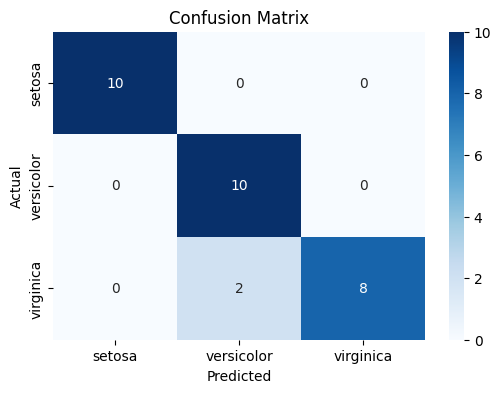

In [18]:
# Confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()